<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=326249618" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [1]:
!pip install torchinfo
import torchinfo
import torch

In [2]:
from training import (
    save_checkpoint, 
    load_checkpoint, 
    train_model_stages,
    plot_learning_curves
)

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze,
    reset_head,
    reset_head_last_fc
)

In [3]:
from model import PseudoAlexNet, DEVICE

In [4]:
from natural_images import (
    load_dataset, 
    stratified_three_way_split,
    visualize_dataset_distribution
)

from screen_images import (
    CustomEnricoDataset,
    plot_image_list
)

## Preparation of the data Caltech101(natural images)

In [5]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.Resize((300,200)),
    v2.RGB(),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
])

transforms_augmented_list = [
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(10),
        
    ]),
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(),
    ])
]

nat_images = load_dataset(data_augmented=True, transforms_original=transforms, transforms_augmented_list=transforms_augmented_list)

100%|██████████| 137M/137M [00:02<00:00, 46.9MB/s]


In [6]:
nat_images_train, nat_images_val, nat_images_test = stratified_three_way_split(dataset=nat_images, train_ratio=0.7, 
                                                                             val_ratio=0.15, test_ratio=0.15, random_state=317)

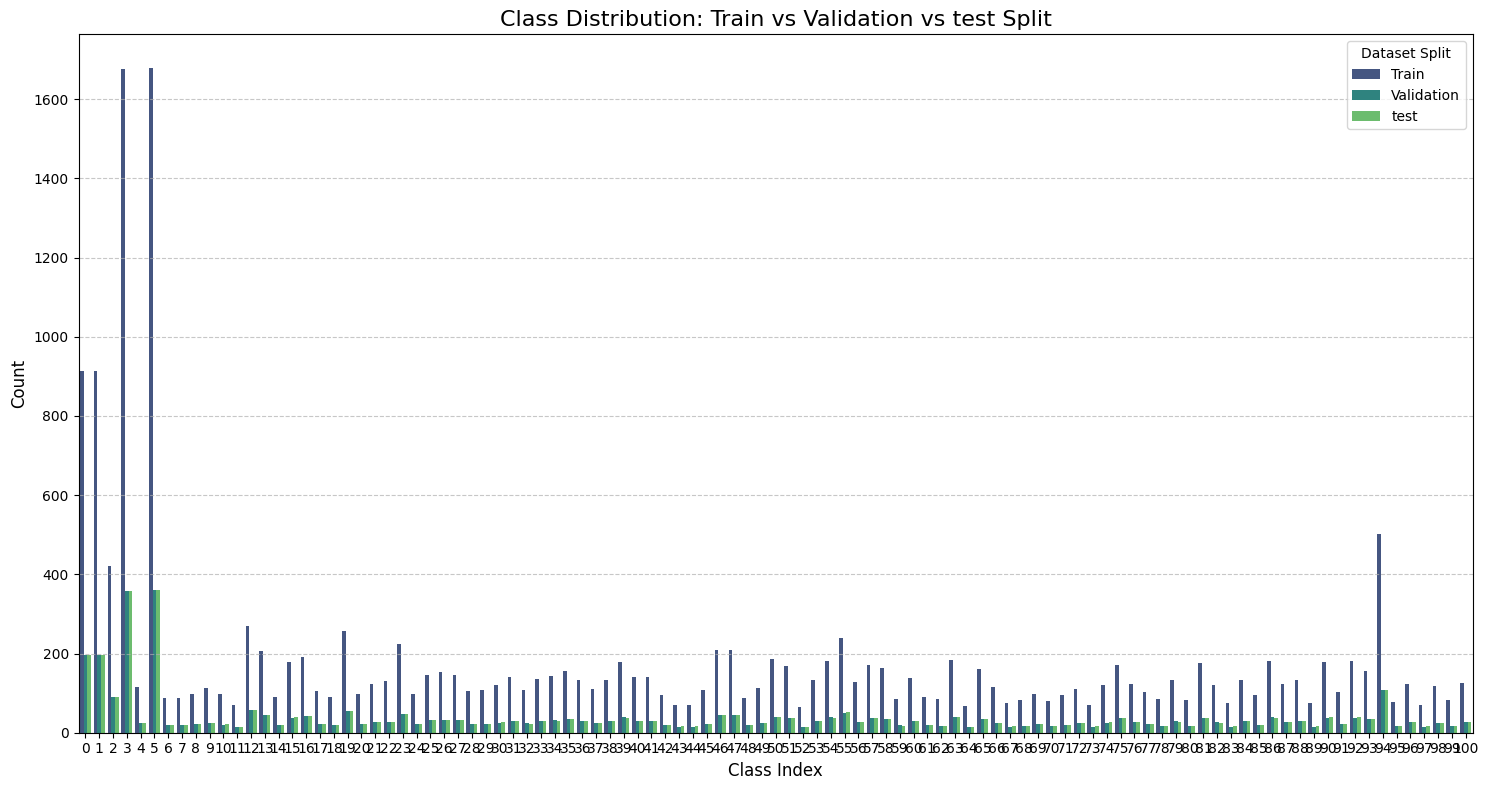

Total Training Samples:   18221 (70.0%)
Total Validation Samples: 3905 (15.0%)
Total test Samples:       3905 (15.0%)
Total Combined Samples:   26031


In [7]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [8]:
batch_size = 128
nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=batch_size, shuffle=True, num_workers=3)
nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=batch_size, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=batch_size, shuffle=False, num_workers=3)

## Training the model on Caltech101

In [9]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 40

model = PseudoAlexNet(tiny_factor=3,p=0) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-3) # adding L2 regularization

val_loss_list_nat = []
train_loss_list_nat = []

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

In [10]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS)

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

=== Training on the nat_images ===
Starting training of the nat_images in 40 epochs.
 nat_images training epoch 1/40...
Train Epoch: 1 [0/18304 (0%)]	Loss: 5.120901
Train Epoch: 1 [384/18304 (2%)]	Loss: 4.815763
Train Epoch: 1 [768/18304 (4%)]	Loss: 4.014567
Train Epoch: 1 [1152/18304 (6%)]	Loss: 3.668570
Train Epoch: 1 [1536/18304 (8%)]	Loss: 3.586793
Train Epoch: 1 [1920/18304 (10%)]	Loss: 3.918435
Train Epoch: 1 [2304/18304 (13%)]	Loss: 3.503344
Train Epoch: 1 [2688/18304 (15%)]	Loss: 3.017604
Train Epoch: 1 [3072/18304 (17%)]	Loss: 3.457195
Train Epoch: 1 [3456/18304 (19%)]	Loss: 2.922374
Train Epoch: 1 [3840/18304 (21%)]	Loss: 3.237922
Train Epoch: 1 [4224/18304 (23%)]	Loss: 2.953520
Train Epoch: 1 [4608/18304 (25%)]	Loss: 2.916564
Train Epoch: 1 [4992/18304 (27%)]	Loss: 2.919305
Train Epoch: 1 [5376/18304 (29%)]	Loss: 2.957680
Train Epoch: 1 [5760/18304 (31%)]	Loss: 2.704287
Train Epoch: 1 [6144/18304 (34%)]	Loss: 2.766136
Train Epoch: 1 [6528/18304 (36%)]	Loss: 2.839916
Train Ep

(0.499476763509935, 0.8878361075544174)

## Plotting training and validation test losses

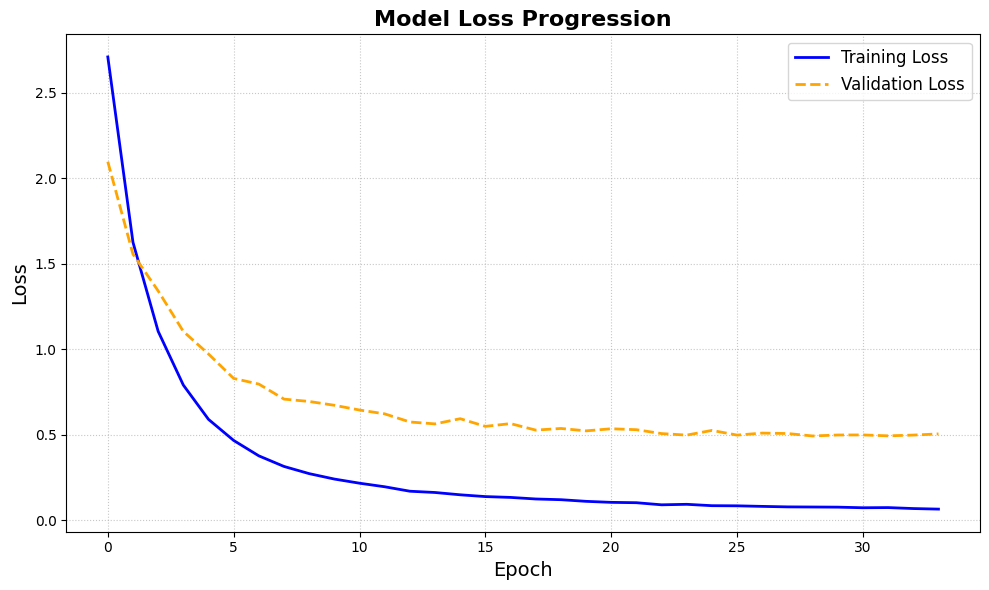

In [11]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat)

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [12]:
from torchvision.transforms import v2
non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x[random.choice(non_identity_perms), :, :]
)

rare_class_aug = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.RandomAffine(degrees=5, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.3, contrast=0.3),
    v2.RandomGrayscale(p=0.2)
])

fatigue_aug = v2.Compose([
    v2.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    v2.ColorJitter(brightness=0.5)
])



augmentations = {
    "dialer": [v2.RandomHorizontalFlip(p=0.5)],
    "camera": [v2.RandomAdjustSharpness(sharpness_factor=2)],
    "maps": [v2.RandomInvert(p=0.2)], 
}

universal_base = v2.Compose([
    v2.RGB(),
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(320, 180)),
    v2.ToDtype(torch.float32, scale=True),
    
])

### 2. Generating training and val dataset

In [13]:
allowed_classes = ["Bare", "Form", "Gallery", "List", "Login", "Menu", "Tutorial"]# the categories which have over 70 samples

allowed_classes = [s.lower() for s in allowed_classes]

small_screen_train_dataset, small_screen_val_dataset, small_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=317,
    transform=universal_base,
    transform_to_class=augmentations,
    augment_for_each=[rare_class_aug],
    allowed_classes=allowed_classes
)

Small example of transformations

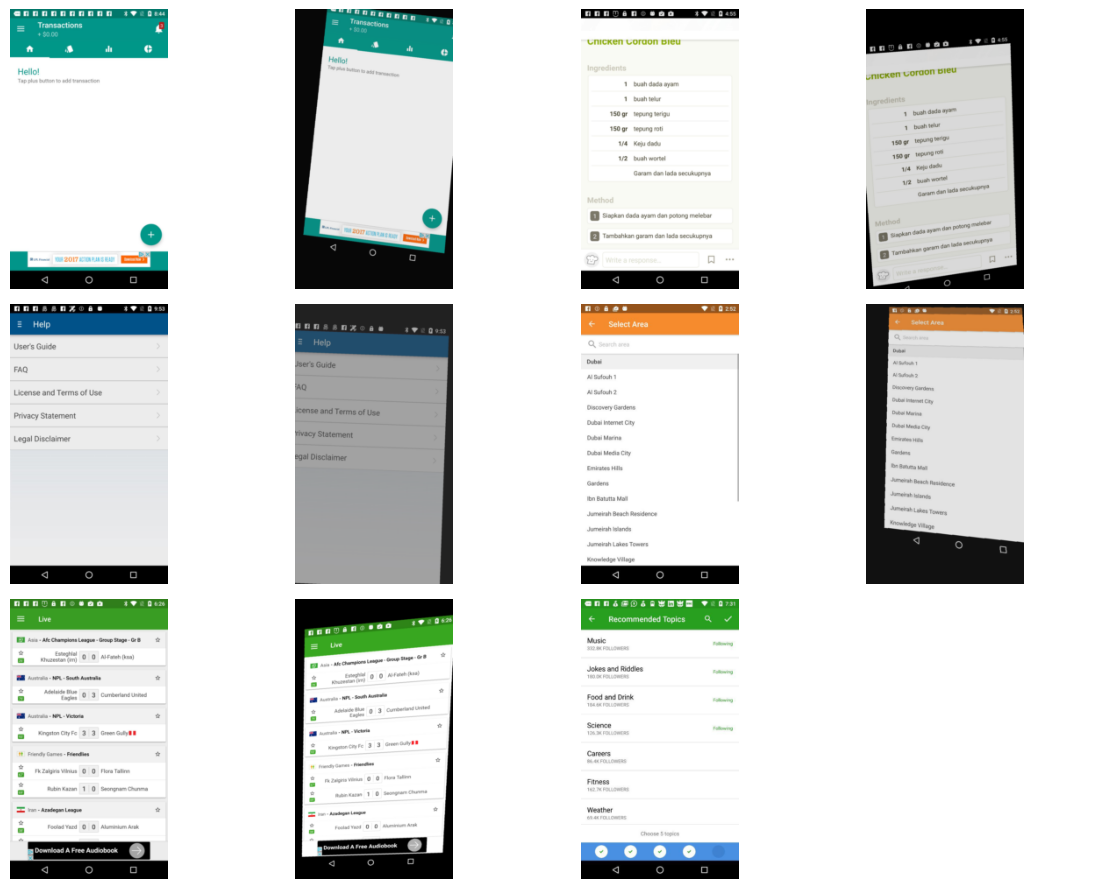

In [14]:
images = small_screen_train_dataset.get_by_label(label="list", num_samples=10)

plot_image_list(images)

In [15]:
batch_size = 128
small_screen_train_loader = torch.utils.data.DataLoader(small_screen_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=3)
small_screen_val_loader = torch.utils.data.DataLoader(small_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
small_screen_test_loader = torch.utils.data.DataLoader(small_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

## Preparation of the model for fine-tuning

### 1. Training on classes with >= 70 only.

Loading the checkpoint after the initial training

In [16]:
checkpoint_path = '/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/finished_nat_images_1_3.pth'
model = PseudoAlexNet(tiny_factor=3,p=0)
print(torchinfo.summary(model))

load_checkpoint(model=model, optimizer=None, path=checkpoint_path, device=DEVICE)

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

(35, 0.48776636488976016)

Adapting a model to the new classification task

### 2. Preparation of the parameters for fine-tuning on allowed classes

In [17]:
import torch.optim
MAX_WARMUP_EPOCHS = 5
MAX_DRIFT_EPOCHS = 10
SEED = 317

reset_head(model, input_features=int((1.0/model.tiny_factor)*32)*40*22, output_features=len(allowed_classes))
model = model.to(DEVICE)

loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

val_loss_list_warmup_1 = []
train_loss_list_warmup_1 = []

val_loss_list_drift_1 = []
train_loss_list_drift_1 = []

### 3. Stage-1 of fine-tuning on the allowed classes

In [18]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_1, val_loss_list_warmup_1 = train_model_stages(model=model, train_loader=small_screen_train_loader, 
                                                            val_loader=small_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_1")

=== Training on the warmup_1 ===
Starting training of the warmup_1 in 5 epochs.
 warmup_1 training epoch 1/5...
Train Epoch: 1 [0/1408 (0%)]	Loss: 1.947617
Train Epoch: 1 [384/1408 (27%)]	Loss: 1.898309
Train Epoch: 1 [768/1408 (55%)]	Loss: 1.805146
Train Epoch: 1 [1152/1408 (82%)]	Loss: 1.729534
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.864329

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.824779, Accuracy: 23.29%

Total time of epoch 1 is 42.14s

 warmup_1 training epoch 2/5...
Train Epoch: 2 [0/1408 (0%)]	Loss: 1.504925
Train Epoch: 2 [384/1408 (27%)]	Loss: 1.577237
Train Epoch: 2 [768/1408 (55%)]	Loss: 1.491669
Train Epoch: 2 [1152/1408 (82%)]	Loss: 1.398834
--- Epoch 2 Training Metrics ---
Average Train Loss: 1.464341

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.634331, Accuracy: 36.64%

Total time of epoch 2 is 42.95s

 warmup_1 training epoch 3/5...
Train Epoch: 3 [0/1408 (0%)]	Loss: 1.399210
Train Epoch: 3 [384/1408 (27%)]	Loss: 1.228149

### 4. Stage-2 of fine-tuning on allowed classes

In [19]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-3
    
train_loss_list_drift_1, val_loss_list_drift_1 = train_model_stages(model=model, train_loader=small_screen_train_loader, 
                                                            val_loader=small_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_1")

evaluate_model(model, small_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_1 ===
Starting training of the drift_1 in 10 epochs.
 drift_1 training epoch 1/10...
Train Epoch: 1 [0/1408 (0%)]	Loss: 1.118369
Train Epoch: 1 [384/1408 (27%)]	Loss: 1.052592
Train Epoch: 1 [768/1408 (55%)]	Loss: 1.079089
Train Epoch: 1 [1152/1408 (82%)]	Loss: 0.925384
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.001553

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.332621, Accuracy: 48.63%

Total time of epoch 1 is 45.35s

 drift_1 training epoch 2/10...
Train Epoch: 2 [0/1408 (0%)]	Loss: 0.925758
Train Epoch: 2 [384/1408 (27%)]	Loss: 0.931438
Train Epoch: 2 [768/1408 (55%)]	Loss: 0.871463
Train Epoch: 2 [1152/1408 (82%)]	Loss: 1.001514
--- Epoch 2 Training Metrics ---
Average Train Loss: 0.955442

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.285832, Accuracy: 52.40%

Total time of epoch 2 is 40.37s

 drift_1 training epoch 3/10...
Train Epoch: 3 [0/1408 (0%)]	Loss: 0.899644
Train Epoch: 3 [384/1408 (27%)]	Loss: 0.895538


(1.2081879377365112, 0.6335616438356164)

### 5. Regenerating the train/val/test split for all classes

In [20]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=SEED,
    transform=universal_base,
    augment_for_each=[rare_class_aug],
    transform_to_class=augmentations,
    allowed_classes=None
)

batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

checkpoint_path = '/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/finished_drift_restricted_max_epochs_1_3.pth'
load_checkpoint(model=model, optimizer=None, path=checkpoint_path, device=DEVICE)

reset_head_last_fc(model, output_features=20)

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 10 | Loss: 1.8570


### 6. Preparation of the parameters for fine-tuning

In [21]:
MAX_WARMUP_EPOCHS = 10
MAX_DRIFT_EPOCHS = 40
SEED = 317

loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
model = model.to(DEVICE)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [22]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2")

=== Training on the warmup_2 ===
Starting training of the warmup_2 in 10 epochs.
 warmup_2 training epoch 1/10...
Train Epoch: 1 [0/2176 (0%)]	Loss: 3.134104
Train Epoch: 1 [384/2176 (18%)]	Loss: 3.047354
Train Epoch: 1 [768/2176 (35%)]	Loss: 3.032411
Train Epoch: 1 [1152/2176 (53%)]	Loss: 2.870125
Train Epoch: 1 [1536/2176 (71%)]	Loss: 2.862953
Train Epoch: 1 [1920/2176 (88%)]	Loss: 2.738891
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.923875

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.786585, Accuracy: 20.45%

Total time of epoch 1 is 60.42s

 warmup_2 training epoch 2/10...
Train Epoch: 2 [0/2176 (0%)]	Loss: 2.373124
Train Epoch: 2 [384/2176 (18%)]	Loss: 2.481571
Train Epoch: 2 [768/2176 (35%)]	Loss: 2.423564
Train Epoch: 2 [1152/2176 (53%)]	Loss: 2.222183
Train Epoch: 2 [1536/2176 (71%)]	Loss: 2.295387
Train Epoch: 2 [1920/2176 (88%)]	Loss: 2.320644
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.332495

--- Epoch 2 Evaluation ---
Validation set: Av

In [23]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-3
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2")

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_2 ===
Starting training of the drift_2 in 40 epochs.
 drift_2 training epoch 1/40...
Train Epoch: 1 [0/2176 (0%)]	Loss: 1.227527
Train Epoch: 1 [384/2176 (18%)]	Loss: 1.531352
Train Epoch: 1 [768/2176 (35%)]	Loss: 1.427217
Train Epoch: 1 [1152/2176 (53%)]	Loss: 1.265594
Train Epoch: 1 [1536/2176 (71%)]	Loss: 1.360567
Train Epoch: 1 [1920/2176 (88%)]	Loss: 1.420616
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.388395

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.991654, Accuracy: 40.91%

Total time of epoch 1 is 61.33s

 drift_2 training epoch 2/40...
Train Epoch: 2 [0/2176 (0%)]	Loss: 1.238414
Train Epoch: 2 [384/2176 (18%)]	Loss: 1.489200
Train Epoch: 2 [768/2176 (35%)]	Loss: 1.359300
Train Epoch: 2 [1152/2176 (53%)]	Loss: 1.241539
Train Epoch: 2 [1536/2176 (71%)]	Loss: 1.264709
Train Epoch: 2 [1920/2176 (88%)]	Loss: 1.420934
--- Epoch 2 Training Metrics ---
Average Train Loss: 1.347749

--- Epoch 2 Evaluation ---
Validation set: Averag

(2.029097259044647, 0.41043083900226757)

### Plotting final train/test split

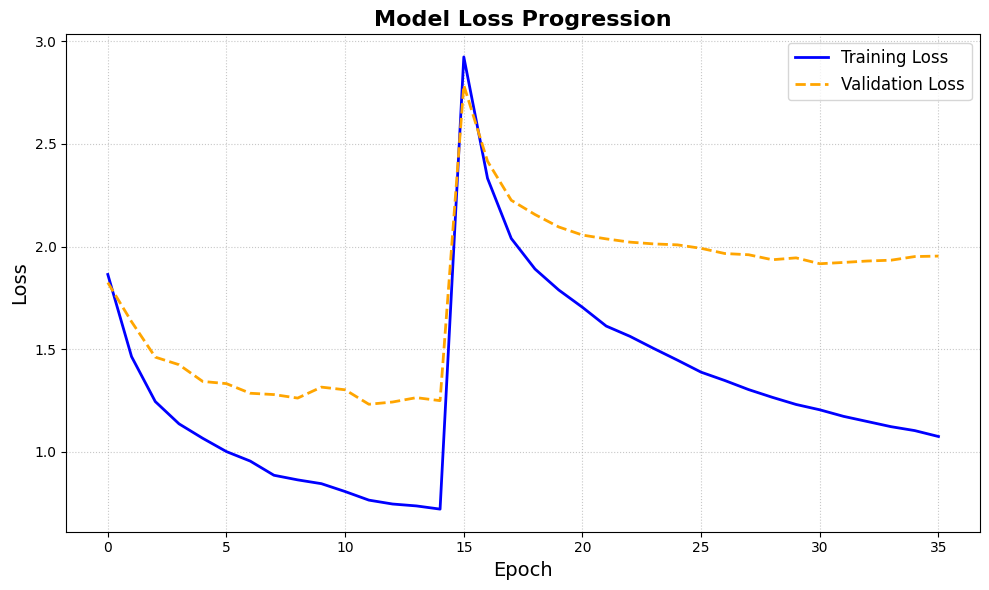

In [24]:
train_loss_list = train_loss_list_warmup_1 + train_loss_list_drift_1 + train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_1 + val_loss_list_drift_1 + val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list)

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [25]:
import torch.optim
MAX_SCREEN_EPOCHS = 40
SEED = 317

full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enrico-dataset-vanilla",
    seed=SEED,
    transform=universal_base,
    augment_for_each=[rare_class_aug],
    transform_to_class=augmentations,
    allowed_classes=None
)

batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

model = PseudoAlexNet(tiny_factor=3, p=0) # with dropout and with LeakyReLU

fc_last_in_features = model.classifier[-1].in_features
model.classifier[1] = nn.Linear(in_features=10*40*22, out_features=fc_last_in_features)
model.classifier[-1] = nn.Linear(in_features=fc_last_in_features, out_features=20) # exactly so much classes are in Enrico

loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-2) # adding L2 regularization

val_loss_list_screen = []
train_loss_list_screen = []

model = model.to(DEVICE)
print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,253,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

=== Training on the screen ===
Starting training of the screen in 40 epochs.
 screen training epoch 1/40...
Train Epoch: 1 [0/2176 (0%)]	Loss: 3.061675
Train Epoch: 1 [384/2176 (18%)]	Loss: 2.904612
Train Epoch: 1 [768/2176 (35%)]	Loss: 2.634063
Train Epoch: 1 [1152/2176 (53%)]	Loss: 2.328382
Train Epoch: 1 [1536/2176 (71%)]	Loss: 2.109026
Train Epoch: 1 [1920/2176 (88%)]	Loss: 2.356751
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.550164

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.499584, Accuracy: 25.45%

Total time of epoch 1 is 59.44s

 screen training epoch 2/40...
Train Epoch: 2 [0/2176 (0%)]	Loss: 1.780929
Train Epoch: 2 [384/2176 (18%)]	Loss: 2.237454
Train Epoch: 2 [768/2176 (35%)]	Loss: 2.035149
Train Epoch: 2 [1152/2176 (53%)]	Loss: 1.862074
Train Epoch: 2 [1536/2176 (71%)]	Loss: 1.928056
Train Epoch: 2 [1920/2176 (88%)]	Loss: 1.956718
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.031332

--- Epoch 2 Evaluation ---
Validation set: Average Lo

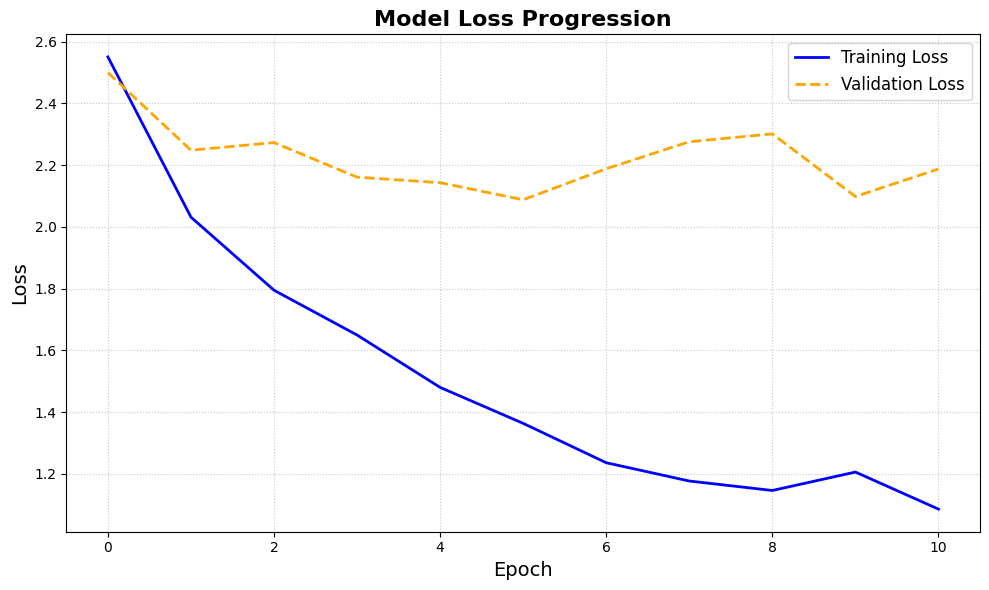

In [26]:
train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen")


evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen)